## 简介
在强化学习中，“模型”通常指与智能体交互的环境模型，即对环境的状态转移概率和奖励函数进行建模。

根据是否具有环境模型，强化学习算法分为两种：
- 基于模型的强化学习（model-based reinforcement learning）
- 无模型的强化学习（model-free reinforcement learning）。

无模型的强化学习根据智能体与环境交互采样到的数据直接进行策略提升或者价值估计
- 第 5 章讨论的两种时序差分算法，即 Sarsa 和 Q-learning 算法，便是两种无模型的强化学习方法，本书在后续章节中将要介绍的方法也大多是无模型的强化学习算法。

在基于模型的强化学习中，模型可以是事先知道的，也可以是根据智能体与环境交互采样到的数据学习得到的，然后用这个模型帮助策略提升或者价值估计。
- 第 4 章讨论的两种动态规划算法，即策略迭代和价值迭代，则是基于模型的强化学习方法，在这两种算法中环境模型是事先已知的。
- 本章即将介绍的 Dyna-Q 算法也是非常基础的基于模型的强化学习算法，不过它的环境模型是通过采样数据估计得到的。

### 强化学习算法有两个重要的评价指标：
- 一个是算法收敛后的策略在初始状态下的期望回报，
- 另一个是样本复杂度，即算法达到收敛结果需要在真实环境中采样的样本数量。

基于模型的强化学习算法由于具有一个环境模型，智能体可以额外和环境模型进行交互，对真实环境中样本的需求量往往就会减少，因此通常会比无模型的强化学习算法具有更低的样本复杂度。**但是，环境模型可能并不准确，不能完全代替真实环境**，因此基于模型的强化学习算法收敛后其策略的期望回报可能不如无模型的强化学习算法。

### Dyna-Q 算法是一个经典的基于模型的强化学习算法。

如图 6-1 所示，Dyna-Q 使用一种叫做 Q-planning 的方法来基于模型生成一些模拟数据，然后用模拟数据和真实数据一起改进策略。
- Q-planning 每次选取一个曾经访问过的状态s，采取一个曾经在该状态下执行过的动作a，通过模型得到转移后的状态$s`$以及奖励r，并根据这个模拟数据$(s,a,r,s`)$，用 Q-learning 的更新方式来更新动作价值函数。

In [1]:
from IPython.display import Image

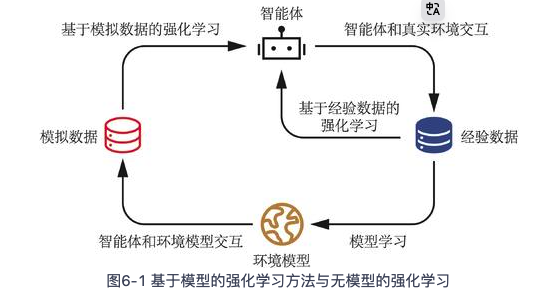

In [3]:
Image(filename='./image/model.png',width=600)

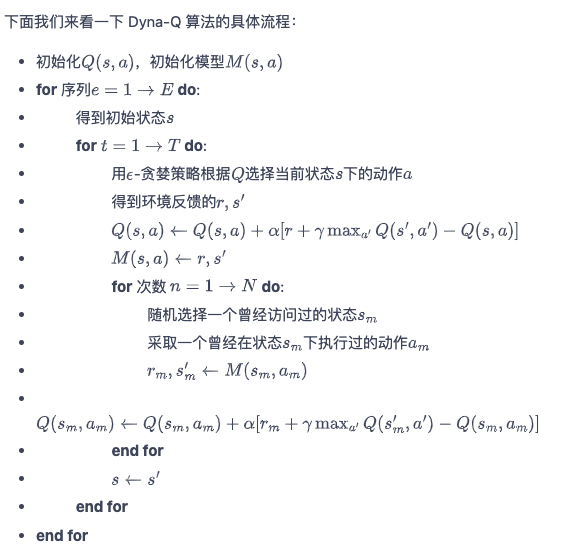

In [4]:
Image(filename='./image/Dyna-Q-step.png',width=600)

可以看到，
- 在每次与环境进行交互执行一次 Q-learning 之后，Dyna-Q 会做n次 Q-planning。
- 其中 Q-planning 的次数N是一个事先可以选择的超参数，
  - 当其为 0 时就是普通的 Q-learning。
值得注意的是，上述 Dyna-Q 算法是执行在一个离散并且确定的环境中，所以当看到一条经验数据$(s,a.r,s`)$时，可以直接对模型做出更新，即M(s,a) ← r,$s`$ 。

## Dyna-Q 代码实践
我们在悬崖漫步环境中执行过 Q-learning 算法，现在也在这个环境中实现 Dyna-Q，以方便比较。首先仍需要实现悬崖漫步的环境代码，和 5.3 节一样。

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random
import time


class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.x = 0  # 记录当前智能体位置的横坐标
        self.y = self.nrow - 1  # 记录当前智能体位置的纵坐标

    def step(self, action):  # 外部调用这个函数来改变当前位置
        # 4种动作, change[0]:上, change[1]:下, change[2]:左, change[3]:右。坐标系原点(0,0)
        # 定义在左上角
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        next_state = self.y * self.ncol + self.x
        reward = -1
        done = False
        if self.y == self.nrow - 1 and self.x > 0:  # 下一个位置在悬崖或者目标
            done = True
            if self.x != self.ncol - 1:
                reward = -100
        return next_state, reward, done

    def reset(self):  # 回归初始状态,起点在左上角
        self.x = 0
        self.y = self.nrow - 1
        return self.y * self.ncol + self.x

然后我们在 Q-learning 的代码上进行简单修改，实现 Dyna-Q 的主要代码。最主要的修改是加入了环境模型model，用一个字典表示，每次在真实环境中收集到新的数据，就把它加入字典。根据字典的性质，若该数据本身存在于字典中，便不会再一次进行添加。在 Dyna-Q 的更新中，执行完 Q-learning 后，会立即执行 Q-planning。

In [6]:
class DynaQ:
    """ Dyna-Q算法 """
    def __init__(self,
                 ncol,
                 nrow,
                 epsilon,
                 alpha,
                 gamma,
                 n_planning,
                 n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # 初始化Q(s,a)表格
        self.n_action = n_action  # 动作个数
        self.alpha = alpha  # 学习率
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略中的参数

        self.n_planning = n_planning  #执行Q-planning的次数, 对应1次Q-learning
        self.model = dict()  # 环境模型

    def take_action(self, state):  # 选取下一步的操作
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def q_learning(self, s0, a0, r, s1):
        td_error = r + self.gamma * self.Q_table[s1].max(
        ) - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error

    def update(self, s0, a0, r, s1):
        self.q_learning(s0, a0, r, s1)
        self.model[(s0, a0)] = r, s1  # 将数据添加到模型中
        for _ in range(self.n_planning):  # Q-planning循环
            # 随机选择曾经遇到过的状态动作对
            (s, a), (r, s_) = random.choice(list(self.model.items()))
            self.q_learning(s, a, r, s_)

下面是 Dyna-Q 算法在悬崖漫步环境中的训练函数，它的输入参数是 Q-planning 的步数。

In [7]:
def DynaQ_CliffWalking(n_planning):
    ncol = 12
    nrow = 4
    env = CliffWalkingEnv(ncol, nrow)
    epsilon = 0.01
    alpha = 0.1
    gamma = 0.9
    agent = DynaQ(ncol, nrow, epsilon, alpha, gamma, n_planning)
    num_episodes = 300  # 智能体在环境中运行多少条序列

    return_list = []  # 记录每一条序列的回报
    for i in range(10):  # 显示10个进度条
        # tqdm的进度条功能
        with tqdm(total=int(num_episodes / 10),
                  desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done = env.step(action)
                    episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                    agent.update(state, action, reward, next_state)
                    state = next_state
                return_list.append(episode_return)
                if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                    pbar.set_postfix({
                        'episode':
                        '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return':
                        '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)
    return return_list

接下来对结果进行可视化，通过调整参数，我们可以观察 Q-planning 步数对结果的影响（另见彩插图 3）。若 Q-planning 步数为 0，Dyna-Q 算法则退化为 Q-learning。

Q-planning步数为：0


Iteration 0: 100%|█| 30/30 [00:00<00:00, 291.09it/s, episode=30, return=-138.400
Iteration 2: 100%|█| 30/30 [00:00<00:00, 371.93it/s, episode=90, return=-46.000]
Iteration 3: 100%|█| 30/30 [00:00<00:00, 590.28it/s, episode=120, return=-38.000
Iteration 4: 100%|█| 30/30 [00:00<00:00, 714.42it/s, episode=150, return=-28.600
Iteration 5: 100%|█| 30/30 [00:00<00:00, 505.22it/s, episode=180, return=-25.300
Iteration 6: 100%|█| 30/30 [00:00<00:00, 577.63it/s, episode=210, return=-23.600
Iteration 7: 100%|█| 30/30 [00:00<00:00, 573.93it/s, episode=240, return=-20.100
Iteration 8: 100%|█| 30/30 [00:00<00:00, 676.21it/s, episode=270, return=-17.100
Iteration 9: 100%|█| 30/30 [00:00<00:00, 503.60it/s, episode=300, return=-16.500


Q-planning步数为：2


Iteration 2: 100%|█| 30/30 [00:00<00:00, 414.37it/s, episode=90, return=-23.600]
Iteration 3: 100%|█| 30/30 [00:00<00:00, 175.47it/s, episode=120, return=-18.500
Iteration 4: 100%|█| 30/30 [00:00<00:00, 368.15it/s, episode=150, return=-16.400
Iteration 5: 100%|█| 30/30 [00:00<00:00, 564.78it/s, episode=180, return=-16.400
Iteration 6: 100%|█| 30/30 [00:00<00:00, 544.46it/s, episode=210, return=-13.400
Iteration 7: 100%|█| 30/30 [00:00<00:00, 636.70it/s, episode=240, return=-13.200
Iteration 8: 100%|█| 30/30 [00:00<00:00, 364.99it/s, episode=270, return=-13.200
Iteration 9: 100%|█| 30/30 [00:00<00:00, 289.10it/s, episode=300, return=-13.500


Q-planning步数为：20


Iteration 2: 100%|█| 30/30 [00:00<00:00, 208.07it/s, episode=90, return=-13.000]
Iteration 3: 100%|█| 30/30 [00:00<00:00, 255.45it/s, episode=120, return=-13.500
Iteration 4: 100%|█| 30/30 [00:00<00:00, 244.07it/s, episode=150, return=-13.500
Iteration 5: 100%|█| 30/30 [00:00<00:00, 228.65it/s, episode=180, return=-13.000
Iteration 6: 100%|█| 30/30 [00:00<00:00, 246.02it/s, episode=210, return=-22.000
Iteration 7: 100%|█| 30/30 [00:00<00:00, 262.83it/s, episode=240, return=-23.200
Iteration 8: 100%|█| 30/30 [00:00<00:00, 250.43it/s, episode=270, return=-13.000
Iteration 9: 100%|█| 30/30 [00:00<00:00, 243.32it/s, episode=300, return=-13.400


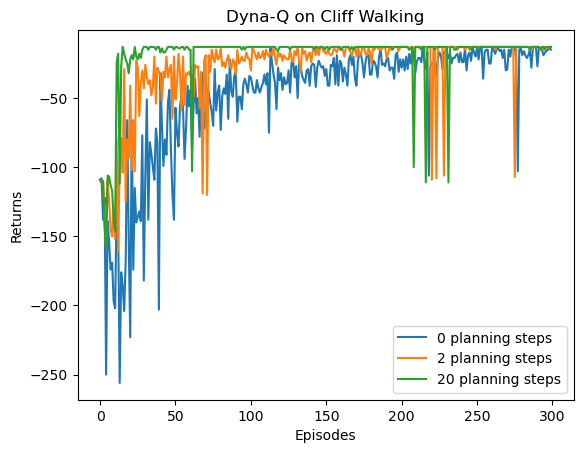

In [8]:
np.random.seed(0)
random.seed(0)
n_planning_list = [0, 2, 20]
for n_planning in n_planning_list:
    print('Q-planning步数为：%d' % n_planning)
    time.sleep(0.5)
    return_list = DynaQ_CliffWalking(n_planning)
    episodes_list = list(range(len(return_list)))
    plt.plot(episodes_list,
             return_list,
             label=str(n_planning) + ' planning steps')
plt.legend()
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dyna-Q on {}'.format('Cliff Walking'))
plt.show()

从上述结果中我们可以很容易地看出，随着 Q-planning 步数的增多，Dyna-Q 算法的收敛速度也随之变快。当然，并不是在所有的环境中，都是 Q-planning 步数越大则算法收敛越快，这取决于环境是否是确定性的，以及环境模型的精度。在上述悬崖漫步环境中，状态的转移是完全确定性的，构建的环境模型的精度是最高的，所以可以通过增加 Q-planning 步数来直接降低算法的样本复杂度。

# 参考文献
[1] SUTTON R S. Dyna, an integrated architecture for learning, planning, and reacting [J]. ACM Sigart Bulletin, 1991 2(4): 160-163.

[2] SUTTON, R S. Integrated architectures for learning, planning, and reacting based on approximating dynamic programming [C]// Proc of International Conference on Machine